# Componente 1: Ingeniería de Datos y Representación de Secuencias
En este notebook desarrollaremos el primer componente del Proyecto 2: Detección de Lavado de Dinero en Remesas.

## Decisiones tomadas:
1. **Subconjunto de Datos:** Se seleccionó `HI-Small_Trans.csv` (~475MB) del dataset de IBM. **Justificación:** Los datasets más grandes superan los límites de memoria locales y de Colab gratuito. Este subset contiene ~5 millones de transacciones con un alto ratio de transacciones ilícitas (HI = High Illicit), asegurando suficientes casos positivos (3,376 remitentes sospechosos) para que el modelo aprenda patrones de lavado sin colapsar la RAM.
2. **Construcción de Secuencias:** Las transacciones se agrupan por `SenderAccount` y se ordenan por `Timestamp`.
3. **Manejo de Desbalance y Partición:** La partición se hará a nivel de *remitentes* para evitar la filtración de datos (Data Leakage) entre secuencias de la misma cuenta.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_theme(style="whitegrid")

## 1. Carga y Exploración Inicial de Datos

In [23]:
file_path = "data/raw/archive ibm/HI-Small_Trans.csv"

# Definir las columnas a usar para ahorrar memoria
cols = [0, 2, 5, 9, 10]
col_names = ["Timestamp", "SenderAccount", "Amount", "PaymentFormat", "IsLaundering"]

print("Cargando dataset...")
df = pd.read_csv(file_path, usecols=cols, names=col_names, header=0)

# Convertir Timestamp a datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
print(f"Total de transacciones: {len(df):,}")
display(df.head())

Cargando dataset...
Total de transacciones: 5,078,345


,Timestamp,SenderAccount,Amount,PaymentFormat,IsLaundering
0,2022-09-01 00:20:00,8000EBD30,3697.34,Reinvestment,0
1,2022-09-01 00:20:00,8000F4580,0.01,Cheque,0
2,2022-09-01 00:00:00,8000F4670,14675.57,Reinvestment,0
3,2022-09-01 00:02:00,8000F5030,2806.97,Reinvestment,0
4,2022-09-01 00:06:00,8000F5200,36682.97,Reinvestment,0


## 2. Ingeniería de Features (Características)
Para que las transacciones aporten valor temporal, extraeremos el día de la semana y la hora del día. En lavado de dinero, las remesas en horas atípicas son fuertes señales de alerta.

In [24]:
# Extraer features temporales
df["Hour"] = df["Timestamp"].dt.hour
df["DayOfWeek"] = df["Timestamp"].dt.dayofweek

# Normalizar el monto con RobustScaler para reducir la influencia de valores extremos (outliers)
scaler = RobustScaler()
df["Amount_Scaled"] = scaler.fit_transform(df[["Amount"]])

# One-Hot Encoding para los formatos de pago
df = pd.get_dummies(df, columns=["PaymentFormat"], drop_first=False)

display(df.head())

,Timestamp,SenderAccount,Amount,IsLaundering,Hour,DayOfWeek,Amount_Scaled,PaymentFormat_ACH,PaymentFormat_Bitcoin,PaymentFormat_Cash,PaymentFormat_Cheque,PaymentFormat_Credit Card,PaymentFormat_Reinvestment,PaymentFormat_Wire
0,2022-09-01 00:20:00,8000EBD30,3697.34,0,0,3,0.187976,False,False,False,False,False,True,False
1,2022-09-01 00:20:00,8000F4580,0.01,0,0,3,-0.116009,False,False,False,True,False,False,False
2,2022-09-01 00:00:00,8000F4670,14675.57,0,0,3,1.090575,False,False,False,False,False,True,False
3,2022-09-01 00:02:00,8000F5030,2806.97,0,0,3,0.114772,False,False,False,False,False,True,False
4,2022-09-01 00:06:00,8000F5200,36682.97,0,0,3,2.899963,False,False,False,False,False,True,False


## 3. Construcción de Secuencias por Remitente
Vamos a agrupar los datos por `SenderAccount`. Una cuenta se considera **sospechosa** si al menos una de sus transacciones es fraude.

In [25]:
print("Agrupando por remitente...")

# Encontrar si un remitente es sospechoso
sender_labels = df.groupby("SenderAccount")["IsLaundering"].max().rename("IsSuspicious")

# Contar cuántas transacciones tiene cada remitente
seq_lengths = df.groupby("SenderAccount").size().rename("SeqLength")

# Unir la metadata de los remitentes
sender_meta = pd.concat([sender_labels, seq_lengths], axis=1)

print(f"Total de remitentes: {len(sender_meta):,}")
print(f"Remitentes sospechosos (positivos): {sender_meta['IsSuspicious'].sum():,}")
print(f"Remitentes normales (negativos): {len(sender_meta) - sender_meta['IsSuspicious'].sum():,}")

Agrupando por remitente...
Total de remitentes: 496,995
Remitentes sospechosos (positivos): 3,376
Remitentes normales (negativos): 493,619


### Visualización Obligatoria: Distribución y Desbalance
Como solicita la rúbrica, vamos a visualizar la distribución de las longitudes de las secuencias y la proporción de casos positivos vs negativos.

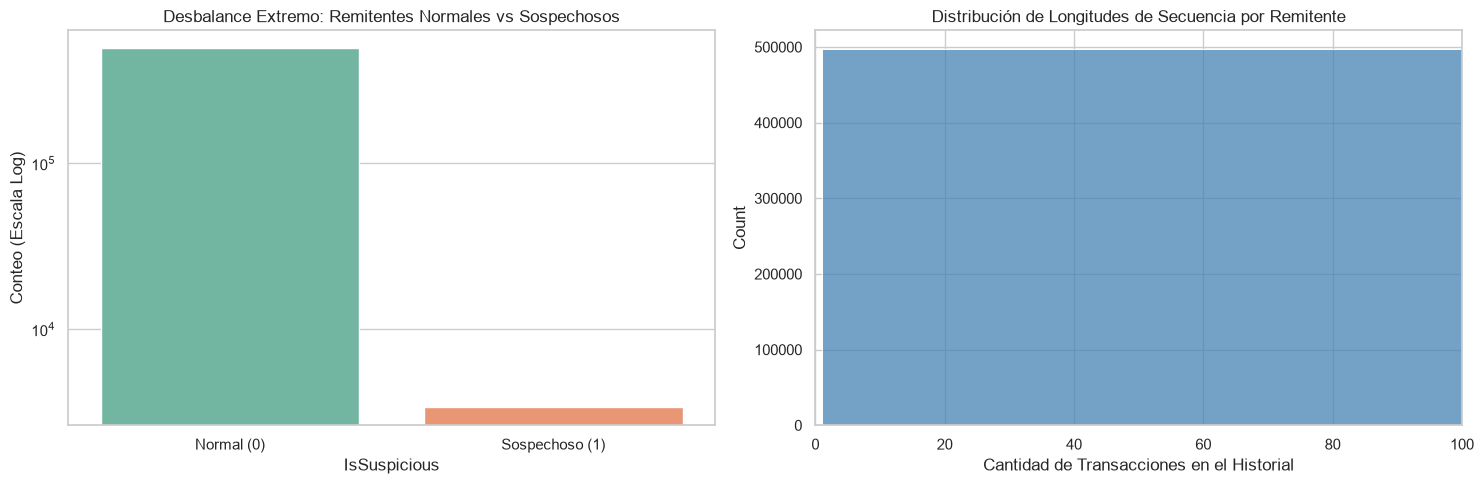

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfica 1: Proporción de Casos
sns.countplot(data=sender_meta, x="IsSuspicious", ax=axes[0], palette="Set2")
axes[0].set_title("Desbalance Extremo: Remitentes Normales vs Sospechosos")
axes[0].set_yscale("log") # Escala logarítmica para poder ver la barra de sospechosos
axes[0].set_ylabel("Conteo (Escala Log)")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Normal (0)", "Sospechoso (1)"])

# Gráfica 2: Distribución de Longitudes de Secuencia
sns.histplot(data=sender_meta, x="SeqLength", bins=50, ax=axes[1], color="steelblue")
axes[1].set_title("Distribución de Longitudes de Secuencia por Remitente")
axes[1].set_xlim(0, 100) # Recortamos la vista para omitir colas muy largas
axes[1].set_xlabel("Cantidad de Transacciones en el Historial")

plt.tight_layout()
plt.show()

## 4. Partición del Dataset (Train/Val/Test) evitando Filtración de Datos (Data Leakage)
La partición se realiza **a nivel de remitentes** (cuentas) y no a nivel de transacciones. Esto asegura que el historial completo de un usuario esté solo en uno de los conjuntos.

Para la **Etapa A (Aprendizaje de Normalidad)**, extraeremos únicamente usuarios normales del set de entrenamiento.

## Componente 2: Sistema de Detección en Dos Etapas
### Etapa A: Aprendizaje de la Normalidad (Autoencoder LSTM)

El objetivo de esta etapa es entrenar un modelo **exclusivamente con datos de remitentes normales**. El modelo aprenderá a comprimir y reconstruir secuencias normales. Cuando se enfrente a una secuencia de lavado de dinero, tendrá un error de reconstrucción alto, lo que nos servirá como "Score de Anomalía".

**Justificación de Arquitectura:** Utilizaremos un Autoencoder basado en celdas LSTM (Long Short-Term Memory). Las LSTM son ideales porque pueden capturar dependencias temporales a largo plazo en las secuencias de transacciones (ej. frecuencias inusuales en días consecutivos).

In [27]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import torch.nn.functional as F

# Configurar dispositivo (GPU si está disponible, según rúbrica)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


#### 1. Preparación de Secuencias y Partición (Splits)
Vamos a construir secuencias de longitud fija (`MAX_SEQ_LEN = 10`). Haremos padding con ceros para secuencias más cortas y truncaremos las más largas (tomando las 10 más recientes).

In [28]:
MAX_SEQ_LEN = 10

# Seleccionar características (features) para el modelo
feature_cols = ['Amount_Scaled', 'Hour', 'DayOfWeek'] + [c for c in df.columns if 'PaymentFormat_' in c]
num_features = len(feature_cols)
print(f"Usando {num_features} features por transacción.")

# Agrupar secuencias por cuenta
print("Construyendo secuencias (esto puede tomar un minuto)...")
grouped = df.sort_values(['SenderAccount', 'Timestamp']).groupby('SenderAccount')

sequences = []
labels = []
accounts = []

for account, group in tqdm(grouped, total=len(sender_meta)):
    # Tomar las últimas MAX_SEQ_LEN transacciones
    seq = group[feature_cols].tail(MAX_SEQ_LEN).values.astype(float)
    
    # Padding si la secuencia es menor a MAX_SEQ_LEN
    if len(seq) < MAX_SEQ_LEN:
        pad = np.zeros((MAX_SEQ_LEN - len(seq), num_features))
        seq = np.vstack([pad, seq])
        
    sequences.append(seq)
    labels.append(sender_meta.loc[account, 'IsSuspicious'])
    accounts.append(account)

sequences = np.array(sequences)
labels = np.array(labels)
accounts = np.array(accounts)
print(f"Secuencias construidas. Shape: {sequences.shape}")

Usando 10 features por transacción.
Construyendo secuencias (esto puede tomar un minuto)...


100%|██████████| 496995/496995 [05:45<00:00, 1440.40it/s]


Secuencias construidas. Shape: (496995, 10, 10)


#### Partición Estratégica (Evitando filtración de datos)
- **Train:** 80% de los datos NORMALES (etiqueta 0).
- **Val:** 10% de NORMALES + 50% de SOSPECHOSOS (para calcular el umbral de anomalía).
- **Test:** 10% de NORMALES + 50% de SOSPECHOSOS.

In [29]:
# Separar índices por clase
normal_idx = np.where(labels == 0)[0]
suspicious_idx = np.where(labels == 1)[0]

# Split normales: 80% Train, 10% Val, 10% Test
train_norm_idx, temp_norm_idx = train_test_split(normal_idx, test_size=0.2, random_state=42)
val_norm_idx, test_norm_idx = train_test_split(temp_norm_idx, test_size=0.5, random_state=42)

# Split sospechosos: 0% Train, 50% Val, 50% Test (Train NO puede tener sospechosos en Etapa A)
val_susp_idx, test_susp_idx = train_test_split(suspicious_idx, test_size=0.5, random_state=42)

# Combinar índices
train_idx = train_norm_idx
val_idx = np.concatenate([val_norm_idx, val_susp_idx])
test_idx = np.concatenate([test_norm_idx, test_susp_idx])

print(f"Train size (solo normales): {len(train_idx)}")
print(f"Val size: {len(val_idx)} (Normales: {len(val_norm_idx)}, Sospechosos: {len(val_susp_idx)})")
print(f"Test size: {len(test_idx)} (Normales: {len(test_norm_idx)}, Sospechosos: {len(test_susp_idx)})")

Train size (solo normales): 394895
Val size: 51050 (Normales: 49362, Sospechosos: 1688)
Test size: 51050 (Normales: 49362, Sospechosos: 1688)


#### 2. Definición del Dataset PyTorch

In [30]:
class RemesasDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.FloatTensor(sequences)
        self.labels = torch.FloatTensor(labels)
        
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

# Crear DataLoaders
BATCH_SIZE = 256
train_loader = DataLoader(RemesasDataset(sequences[train_idx], labels[train_idx]), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(RemesasDataset(sequences[val_idx], labels[val_idx]), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(RemesasDataset(sequences[test_idx], labels[test_idx]), batch_size=BATCH_SIZE, shuffle=False)

#### 3. Arquitectura del LSTM Autoencoder
Se implementa un Encoder que reduce la dimensión temporal a un vector latente, y un Decoder que intenta reconstruir la secuencia a partir de ese vector.

In [31]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, seq_len, n_features, embedding_dim=32):
        super(LSTMAutoencoder, self).__init__()
        self.seq_len = seq_len
        self.n_features = n_features
        self.embedding_dim = embedding_dim
        
        # Encoder
        self.encoder_lstm1 = nn.LSTM(n_features, 64, batch_first=True)
        self.encoder_lstm2 = nn.LSTM(64, embedding_dim, batch_first=True)
        
        # Decoder
        self.decoder_lstm1 = nn.LSTM(embedding_dim, 64, batch_first=True)
        self.decoder_lstm2 = nn.LSTM(64, n_features, batch_first=True)
        
    def forward(self, x):
        # x shape: (batch_size, seq_len, n_features)
        
        # ENCODER
        x, (_, _) = self.encoder_lstm1(x)
        _, (hidden, _) = self.encoder_lstm2(x)
        # hidden shape: (1, batch_size, embedding_dim) -> reshape a (batch_size, embedding_dim)
        hidden = hidden.squeeze(0)
        
        # DECODER
        # Repetir el vector oculto seq_len veces para alimentar el decoder
        x = hidden.unsqueeze(1).repeat(1, self.seq_len, 1)
        x, (_, _) = self.decoder_lstm1(x)
        x, (_, _) = self.decoder_lstm2(x)
        
        return x, hidden

model_A = LSTMAutoencoder(seq_len=MAX_SEQ_LEN, n_features=num_features, embedding_dim=16).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_A.parameters(), lr=1e-3)
print(model_A)

LSTMAutoencoder(
  (encoder_lstm1): LSTM(10, 64, batch_first=True)
  (encoder_lstm2): LSTM(64, 16, batch_first=True)
  (decoder_lstm1): LSTM(16, 64, batch_first=True)
  (decoder_lstm2): LSTM(64, 10, batch_first=True)
)


#### 4. Entrenamiento de la Etapa A (Aprendizaje de Normalidad)
Entrenamos el modelo para minimizar el Error Cuadrático Medio (MSE) de reconstrucción.

Iniciando entrenamiento...


Epoch 1/10: 100%|██████████| 1543/1543 [00:20<00:00, 75.94it/s]


Epoch [1/10] Loss: 359204884.178632


Epoch 2/10: 100%|██████████| 1543/1543 [00:18<00:00, 83.16it/s]


Epoch [2/10] Loss: 359204876.306544


...

Epoch [8/10] Loss: 359204879.864362


Epoch 9/10: 100%|██████████| 1543/1543 [00:18<00:00, 84.43it/s]


Epoch [9/10] Loss: 359205246.333985


Epoch 10/10: 100%|██████████| 1543/1543 [00:18<00:00, 85.09it/s]


Epoch [10/10] Loss: 359282048.925908


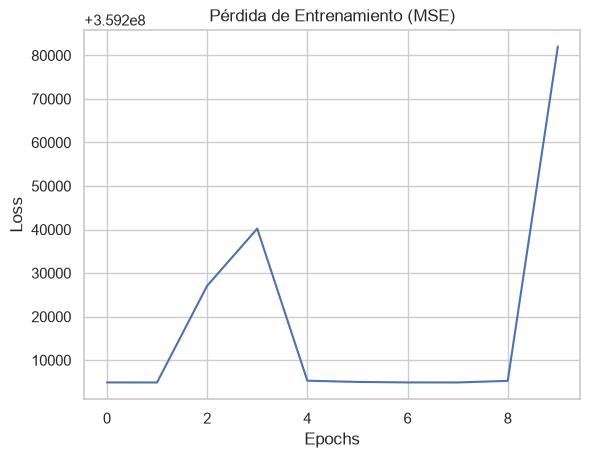

In [32]:
EPOCHS = 10
train_losses = []

print("Iniciando entrenamiento...")
for epoch in range(EPOCHS):
    model_A.train()
    epoch_loss = 0
    
    for seq, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        seq = seq.to(device)
        
        optimizer.zero_grad()
        reconstructed, _ = model_A(seq)
        
        loss = criterion(reconstructed, seq)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {avg_loss:.6f}")

plt.plot(train_losses)
plt.title('Pérdida de Entrenamiento (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

#### 5. Definición del Umbral de Anomalía (Evaluación)
Usaremos el conjunto de validación (`val_loader`) para calcular el error de reconstrucción (Anomalía Score) de cada secuencia.

**Justificación del Umbral:** Utilizaremos la curva Precision-Recall para encontrar el umbral de error de reconstrucción que maximice el F1-Score en el conjunto de validación, dado que tenemos un dataset altamente desbalanceado.

Umbral Óptimo de Anomalía: 31.016287
Mejor F1-Score en Validación: 0.1329


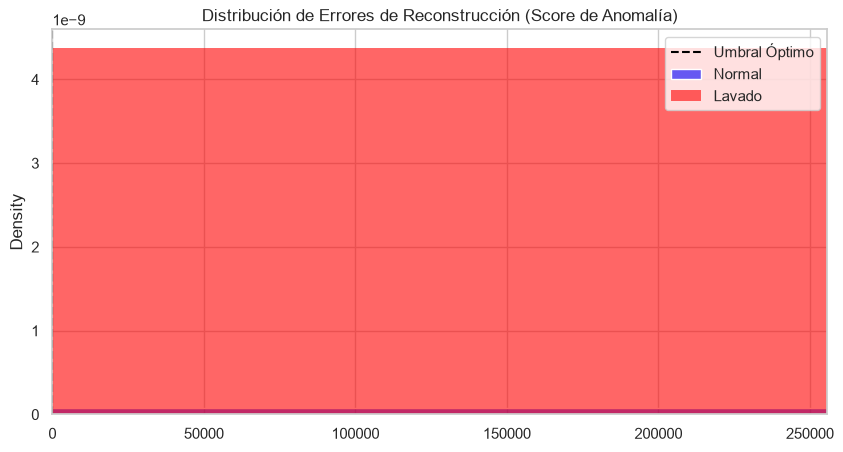

In [33]:
from sklearn.metrics import precision_recall_curve, f1_score, auc

def get_reconstruction_errors(model, dataloader):
    model.eval()
    errors = []
    labels_list = []
    
    with torch.no_grad():
        for seq, lbl in dataloader:
            seq = seq.to(device)
            reconstructed, _ = model(seq)
            
            # Error de reconstrucción por cada muestra en el batch (MSE)
            mse = torch.mean((reconstructed - seq)**2, dim=[1, 2])
            errors.extend(mse.cpu().numpy())
            labels_list.extend(lbl.numpy())
            
    return np.array(errors), np.array(labels_list)

val_errors, val_lbls = get_reconstruction_errors(model_A, val_loader)

# Encontrar umbral óptimo maximizando F1-Score
precisions, recalls, thresholds = precision_recall_curve(val_lbls, val_errors)
f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-8)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Umbral Óptimo de Anomalía: {optimal_threshold:.6f}")
print(f"Mejor F1-Score en Validación: {f1_scores[optimal_idx]:.4f}")

# Visualizar distribución de errores
plt.figure(figsize=(10, 5))
sns.histplot(val_errors[val_lbls==0], bins=50, color='blue', alpha=0.6, label='Normal', stat='density')
sns.histplot(val_errors[val_lbls==1], bins=50, color='red', alpha=0.6, label='Lavado', stat='density')
plt.axvline(optimal_threshold, color='black', linestyle='--', label='Umbral Óptimo')
plt.title('Distribución de Errores de Reconstrucción (Score de Anomalía)')
plt.xlim(0, np.percentile(val_errors, 99)) # Recortar outliers para mejor visualización
plt.legend()
plt.show()